[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Clases/Clase20260428.ipynb)

Expresión original r(f):


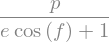


Derivada dr/df (sin simplificar):


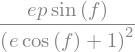


Derivada dr/df (simplificada):


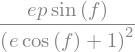

In [8]:
import sympy as sp

# 1. Definir las variables simbólicas
p, e, f = sp.symbols('p e f')

# 2. Definir la expresión de r
r = p / (1 + e * sp.cos(f))

# 3. Calcular la derivada de r respecto a f
dr_df = sp.diff(r, f)

# 4. Simplificar el resultado (recomendado)
dr_df_simplificado = sp.simplify(dr_df)

# 5. Mostrar los resultados en consola
print("Expresión original r(f):")
display(r)

print("\nDerivada dr/df (sin simplificar):")
display(dr_df)
print("\nDerivada dr/df (simplificada):")
display(dr_df_simplificado)

Para pasar la expresión corregida a coordenadas cartesianas, sustituimos los vectores unitales orbitales $\hat{e}_r$ y $\hat{e}_f$ por sus componentes en la base cartesiana $\{\hat{i}, \hat{j}\}$, donde el eje $x$ apunta hacia el periapsis y el eje $y$ es perpendicular en el plano de la órbita.

### 1. Relación entre vectores unitarios

$$
\hat{e}_r = \cos f \, \hat{i} + \sin f \, \hat{j}
$$

$$
\hat{e}_f = -\sin f \, \hat{i} + \cos f \, \hat{j}
$$

### 2. Sustitución en la expresión

Sea $K = \dfrac{\mu}{h}$ para simplificar la notación. La expresión original es:

$$
\vec{v} = K \left[ e\sin f \, \hat{e}_r + (1+e\cos f) \, \hat{e}_f \right]
$$

Sustituimos los vectores unitarios:

$$
\vec{v} = K \left[ e\sin f (\cos f \, \hat{i} + \sin f \, \hat{j}) + (1+e\cos f) (-\sin f \, \hat{i} + \cos f \, \hat{j}) \right]
$$

### 3. Desarrollo y agrupación por componentes

Expandimos los productos y separamos las componentes $\hat{i}$ y $\hat{j}$:

$$
\vec{v} = K \left[ \Big( e\sin f \cos f - (1+e\cos f)\sin f \Big) \hat{i} + \Big( e\sin^2 f + (1+e\cos f)\cos f \Big) \hat{j} \right]
$$

**Componente $x$ ($\hat{i}$):**

$$
v_x = K \left[ e\sin f \cos f - \sin f - e\cos f \sin f \right]
$$

$$
v_x = K \left[ -\sin f \right]
$$

**Componente $y$ ($\hat{j}$):**

$$
v_y = K \left[ e\sin^2 f + \cos f + e\cos^2 f \right]
$$

$$
v_y = K \left[ e(\sin^2 f + \cos^2 f) + \cos f \right]
$$

$$
v_y = K \left[ e + \cos f \right]
$$

### 4. Resultado final en cartesianas

Restituyendo $K = \dfrac{\mu}{h}$:

$$
\boxed{\vec{v} = \frac{\mu}{h} \left( -\sin f \, \hat{i} + (e + \cos f) \, \hat{j} \right)}
$$

Esta expresión coincide exactamente con la forma estándar del vector velocidad en el sistema perifocal de mecánica orbital.

Lo anterior me sirve para construír el hodografo

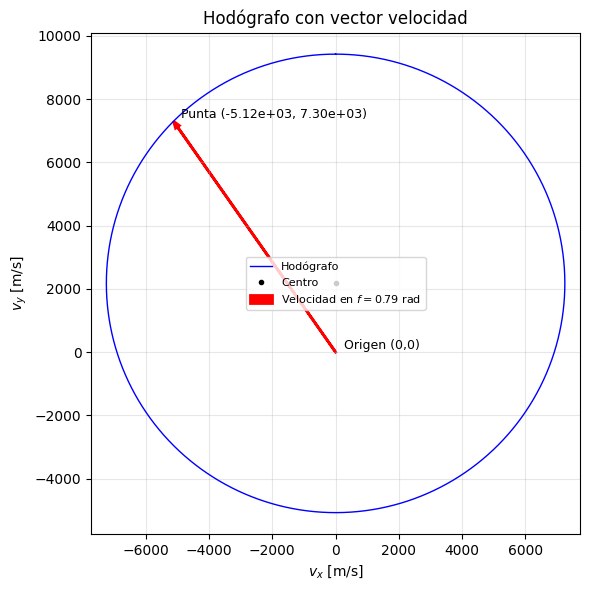

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros orbitales
mu = 3.986e14
h = 5.5e10
e = 0.3

V0 = mu / h

# Anomalía verdadera
f = np.linspace(0, 2*np.pi, 1000)

# Componentes de la velocidad
vx = -V0 * np.sin(f)
vy = V0 * (e + np.cos(f))

# Valor arbitrario de f para mostrar el vector
f_arrow = np.pi / 4
vx_arrow = -V0 * np.sin(f_arrow)
vy_arrow = V0 * (e + np.cos(f_arrow))

# Gráfico
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(vx, vy, 'b-', linewidth=1, label='Hodógrafo')
ax.plot(0, V0*e, 'ko', markersize=3, label='Centro')

# Vector velocidad en f arbitrario: desde origen (0,0) hasta (vx_arrow, vy_arrow)
ax.arrow(0, 0, vx_arrow, vy_arrow, head_width=0.02*V0, head_length=0.03*V0,
         fc='red', ec='red', linewidth=2, length_includes_head=True,
         label=f'Velocidad en $f={f_arrow:.2f}$ rad')

# Etiquetas en los extremos del vector
ax.text(0, 0, '  Origen (0,0)', ha='left', va='bottom', fontsize=9)
ax.text(vx_arrow, vy_arrow, f'  Punta ({vx_arrow:.2e}, {vy_arrow:.2e})',
        ha='left', va='bottom', fontsize=9)

ax.set_xlabel(r'$v_x$ [m/s]')
ax.set_ylabel(r'$v_y$ [m/s]')
ax.set_title('Hodógrafo con vector velocidad')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ¿Qué me está diciendo $h$ en el hodografo?

En el hodógrafo, $h$ es el **momento angular específico** ($h = |\vec{r} \times \vec{v}|$) y actúa como el **factor de escala de velocidades**.

### Efectos directos en el hodógrafo:

Con $V_0 = \mu/h$:

| Parámetro del hodógrafo | Dependencia de $h$ | Interpretación |
|------------------------|-------------------|---------------|
| Radio del círculo | $V_0 = \mu/h$ | A mayor $h$, menor radio (velocidades más pequeñas) |
| Desplazamiento del centro | $e\mu/h$ | El centro se acerca al origen cuando $h$ aumenta |
| Área encerrada | $\pi(\mu/h)^2$ | Relacionada con la energía de la órbita |

### Interpretación física:

1. **$h$ constante**: En movimiento kepleriano, $h$ se conserva, por eso el hodógrafo es un círculo perfecto y no una espiral.

2. **Relación con la geometría orbital**:
   $$
   p = \frac{h^2}{\mu} \quad \Rightarrow \quad h = \sqrt{\mu p}
   $$
   donde $p$ es el semi-latus rectum. Órbitas más "anchas" (mayor $p$) tienen mayor $h$ y, por tanto, hodógrafos más pequeños.

3. **Límites**:
   - $h \to \infty$: hodógrafo colapsa a un punto (movimiento rectilíneo o velocidad nula)
   - $h \to 0$: hodógrafo diverge (caída radial o colisión)

### En resumen:
$h$ no cambia la forma circular del hodógrafo, pero determina su tamaño absoluto. Conocer $h$ permite pasar del hodógrafo adimensional (en unidades de $V_0$) a velocidades físicas en m/s.

¿Necesitas que muestre cómo varía el hodógrafo al modificar $h$ manteniendo $e$ constante?